In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_brain.transforms import UnitFilter, Compose

from mlp import MLPNeuralClassifier
from aux_functions import (
    get_loaders,
    get_unit_ids,
    move_to_device,
    training_step,
    compute_classification_metrics,
)

In [3]:
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda:0") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

# ── Hyperparameters ────────────────────────────────────────────────────────
BIN_SIZE        = 10e-3   # 10 ms → 100 input bins / second
SEQUENCE_LENGTH = 1.0     # 1-second windows
HIDDEN_DIM      = 256
NUM_EPOCHS      = 10
LR              = 1e-4
QUALITY_SCORE   = 0.6

# ── Task ───────────────────────────────────────────────────────────────────
TASK_CLS  = "choice"         # task-aligned interval name in the h5 files
LABEL_MAP = {"left": 0, "right": 1}   # IBL choice strings: left=0, right=1

Using device: mps


In [4]:
recording_ids = [
    #"sub-CSHL059_ses-d2f5a130-b981-4546-8858-c94ae1da75ff_desc-processed_behavior+ecephys",
    #"sub-NYU-21_ses-8c33abef-3d3e-4d42-9f27-445e9def08f9_desc-processed_behavior+ecephys",
    "sub-UCLA035_ses-6f36868f-5cc1-450c-82fa-6b9829ce0cfe_desc-processed_behavior+ecephys",
    #"sub-DY-011_ses-7bee9f09-a238-42cf-b499-f51f765c6ded_desc-processed_behavior+ecephys",
    #"sub-DY-014_ses-bd456d8f-d36e-434a-8051-ff3997253802_desc-processed_behavior+ecephys",
    #"sub-NR-0027_ses-ae8787b1-4229-4d56-b0c2-566b61a25b77_desc-processed_behavior+ecephys",
    #"sub-SWC-038_ses-03063955-2523-47bd-ae57-f7489dd40f15_desc-processed_behavior+ecephys",
    #"sub-ZFM-01936_ses-4aa1d525-5c7d-4c50-a147-ec53a9014812_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-81a78eac-9d36-4f90-a73a-7eb3ad7f770b_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-626126d5-eecf-4e9b-900e-ec29a17ece07_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-b69b86be-af7d-4ecf-8cbf-0cd356afa1bd_desc-processed_behavior+ecephys",
    #"sub-CSH-ZAD-026_ses-e56541a5-a6d5-4750-b1fe-f6b5257bfe7c_desc-processed_behavior+ecephys",
]

dir_path = Path(".").resolve()

dataset_cls, train_loader_cls, val_loader_cls, test_loader_cls = get_loaders(
    dir_path=dir_path,
    recording_ids=recording_ids,
    readout_id="wheel_velocity",   # normalization stats only; values not used for cls
    task="choice",
    window_length=SEQUENCE_LENGTH,
    batch_size=16,
)

print(f"Recordings  : {len(dataset_cls.recording_ids)}")
print(f"Total units : {len(dataset_cls.get_unit_ids())}")
print(f"Train batches: {len(train_loader_cls)}  |  Val: {len(val_loader_cls)}  |  Test: {len(test_loader_cls)}")

Recordings  : 1
Total units : 2856
Train batches: 44  |  Val: 7  |  Test: 13


In [5]:
experiments_cls = {
    "motor":        {"filter_strs": ["motor"]},
    "caudoputamen": {"filter_strs": ["caudoputamen"]},
    "both":         {"filter_strs": ["motor", "caudoputamen"]},
}

cls_models       = {}
cls_loss_logs    = {}
cls_mcc_logs     = {}
cls_unit_filters = {}

for label, cfg in experiments_cls.items():
    unit_ids = get_unit_ids(dataset_cls, filter_str=cfg["filter_strs"], quality_score=QUALITY_SCORE)
    print(f"\n── {label}  ({len(unit_ids)} units) ──")

    valid_set   = set(unit_ids)
    unit_filter = UnitFilter(
        mask_fn=lambda units, vs=valid_set: np.array([uid in vs for uid in units.id]),
        field="spikes",
        reset_index=True,
    )
    cls_unit_filters[label] = unit_filter

    model = MLPNeuralClassifier(
        num_units=len(unit_ids),
        bin_size=BIN_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        task=TASK_CLS,
        num_classes=2,
        label_map=LABEL_MAP,
        hidden_dim=HIDDEN_DIM,
    ).to(device).float()

    dataset_cls.transform = Compose([unit_filter, model.tokenize])
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    loss_log = []
    mcc_log  = []
    for epoch in range(NUM_EPOCHS):
        # ── validation before training (analogous to compute_r2 in regression) ──
        val_metrics = compute_classification_metrics(val_loader_cls, model)
        mcc_log.append(val_metrics["mcc"])

        # ── training ──
        model.train()
        epoch_loss = 0.0
        for batch in train_loader_cls:
            batch = move_to_device(batch, device)
            loss = training_step(batch, model, optimizer, task_type="classification")
            loss_log.append(loss.item())
            epoch_loss += loss.item()
        print(f"  Epoch {epoch+1:3d}/{NUM_EPOCHS}  loss={epoch_loss/len(train_loader_cls):.4f}  val_MCC={val_metrics['mcc']:.3f}  bal_acc={val_metrics['bal_acc']:.3f}")

    # final validation
    val_metrics = compute_classification_metrics(val_loader_cls, model)
    mcc_log.append(val_metrics["mcc"])

    cls_models[label]    = model
    cls_loss_logs[label] = loss_log
    cls_mcc_logs[label]  = mcc_log
    print(f"\u2705 {label} done  final val MCC={val_metrics['mcc']:.3f}  AUROC={val_metrics['auroc']:.3f}")


── motor  (160 units) ──
  Epoch   1/10  loss=0.6166  val_MCC=-0.127  bal_acc=0.475
  Epoch   2/10  loss=0.2673  val_MCC=0.695  bal_acc=0.847
  Epoch   3/10  loss=0.0527  val_MCC=0.859  bal_acc=0.925
  Epoch   4/10  loss=0.0133  val_MCC=0.799  bal_acc=0.901
  Epoch   5/10  loss=0.0058  val_MCC=0.780  bal_acc=0.892
  Epoch   6/10  loss=0.0032  val_MCC=0.799  bal_acc=0.901
  Epoch   7/10  loss=0.0021  val_MCC=0.824  bal_acc=0.915
  Epoch   8/10  loss=0.0014  val_MCC=0.842  bal_acc=0.924
  Epoch   9/10  loss=0.0010  val_MCC=0.824  bal_acc=0.915
  Epoch  10/10  loss=0.0007  val_MCC=0.824  bal_acc=0.915
✅ motor done  final val MCC=0.824  AUROC=0.980

── caudoputamen  (283 units) ──
  Epoch   1/10  loss=0.4366  val_MCC=0.135  bal_acc=0.551
  Epoch   2/10  loss=0.0570  val_MCC=0.940  bal_acc=0.966
  Epoch   3/10  loss=0.0105  val_MCC=0.980  bal_acc=0.989
  Epoch   4/10  loss=0.0039  val_MCC=0.980  bal_acc=0.989
  Epoch   5/10  loss=0.0021  val_MCC=0.980  bal_acc=0.989
  Epoch   6/10  loss=0.

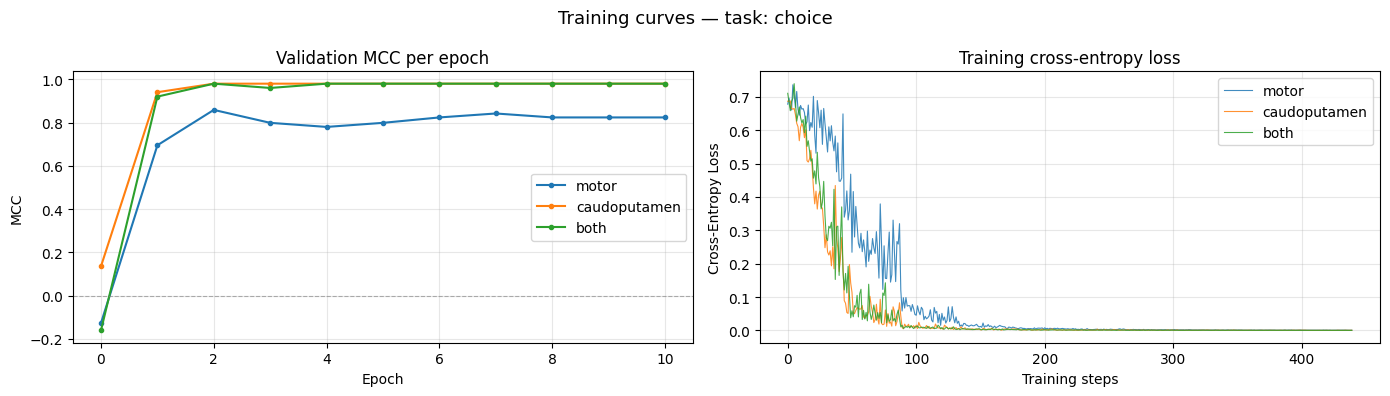

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label in cls_models:
    axes[0].plot(cls_mcc_logs[label], label=label, marker="o", markersize=3)
    axes[1].plot(cls_loss_logs[label], label=label, linewidth=0.8, alpha=0.85)

axes[0].set_title("Validation MCC per epoch", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MCC")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("Training cross-entropy loss", fontsize=12)
axes[1].set_xlabel("Training steps")
axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"Training curves — task: {TASK_CLS}", fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import (
    matthews_corrcoef, balanced_accuracy_score, roc_auc_score,
    confusion_matrix, roc_curve, auc,
)

cls_test_metrics     = {}
cls_test_probs       = {}
cls_test_preds       = {}
cls_test_targets_arr = {}

for label, m in cls_models.items():
    dataset_cls.transform = Compose([cls_unit_filters[label], m.tokenize])
    m.eval()
    all_preds, all_probs, all_targets = [], [], []
    with torch.no_grad():
        for batch in test_loader_cls:
            batch  = move_to_device(batch, device)
            logits = m(**batch["model_inputs"])
            probs  = torch.softmax(logits, dim=-1)[:, 1].cpu()
            pred   = logits.argmax(dim=-1).cpu()
            tgt    = batch["target_values"].cpu()
            all_preds.append(pred)
            all_probs.append(probs)
            all_targets.append(tgt)

    preds   = torch.cat(all_preds).numpy()
    probs   = torch.cat(all_probs).numpy()
    targets = torch.cat(all_targets).numpy()

    cls_test_metrics[label]     = {
        "mcc":     float(matthews_corrcoef(targets, preds)),
        "bal_acc": float(balanced_accuracy_score(targets, preds)),
        "auroc":   float(roc_auc_score(targets, probs)),
    }
    cls_test_probs[label]        = probs
    cls_test_preds[label]        = preds
    cls_test_targets_arr[label]  = targets

    met = cls_test_metrics[label]
    print(f"{label:15s}  MCC={met['mcc']:.3f}  bal_acc={met['bal_acc']:.3f}  AUROC={met['auroc']:.3f}")

motor            MCC=0.820  bal_acc=0.911  AUROC=0.972
caudoputamen     MCC=0.910  bal_acc=0.954  AUROC=0.990
both             MCC=0.900  bal_acc=0.950  AUROC=0.992


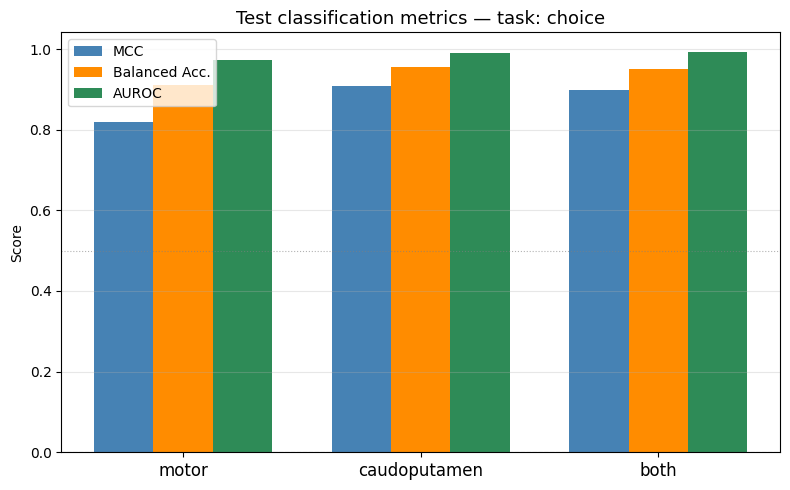

In [8]:
labels_list = list(cls_test_metrics.keys())
mcc_vals    = [cls_test_metrics[l]["mcc"]     for l in labels_list]
bacc_vals   = [cls_test_metrics[l]["bal_acc"] for l in labels_list]
auroc_vals  = [cls_test_metrics[l]["auroc"]   for l in labels_list]

x     = np.arange(len(labels_list))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, mcc_vals,   width, label="MCC",           color="steelblue")
ax.bar(x,         bacc_vals,  width, label="Balanced Acc.", color="darkorange")
ax.bar(x + width, auroc_vals, width, label="AUROC",         color="seagreen")

ax.axhline(0,   color="gray", linestyle="--", linewidth=0.8, alpha=0.6)  # MCC chance
ax.axhline(0.5, color="gray", linestyle=":",  linewidth=0.8, alpha=0.6)  # bal_acc / AUROC chance

ax.set_xticks(x)
ax.set_xticklabels(labels_list, fontsize=12)
ax.set_ylabel("Score")
ax.set_title(f"Test classification metrics — task: {TASK_CLS}", fontsize=13)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


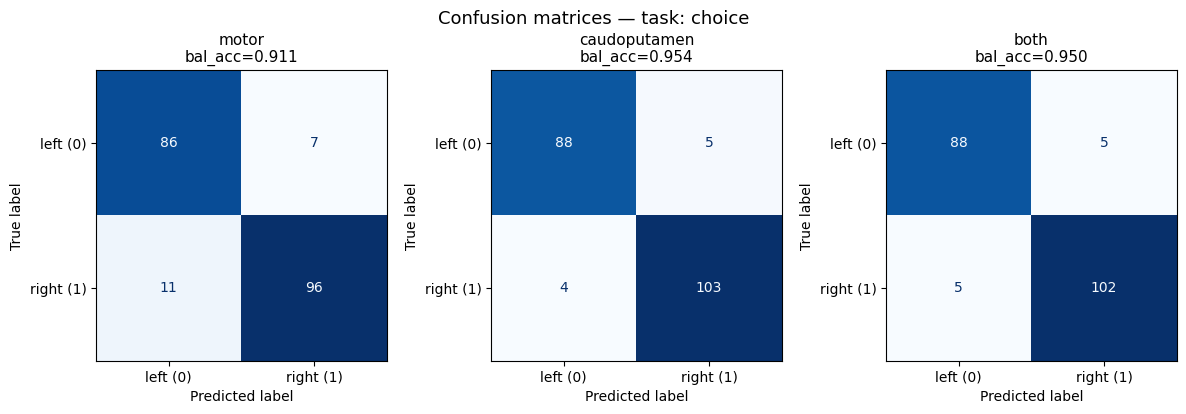

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

class_names = ["left (0)", "right (1)"]
fig, axes = plt.subplots(1, len(cls_models), figsize=(4 * len(cls_models), 4))

for ax, label in zip(axes, cls_models):
    cm = confusion_matrix(cls_test_targets_arr[label], cls_test_preds[label])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{label}\nbal_acc={cls_test_metrics[label]['bal_acc']:.3f}", fontsize=11)

fig.suptitle(f"Confusion matrices — task: {TASK_CLS}", fontsize=13)
plt.tight_layout()
plt.show()


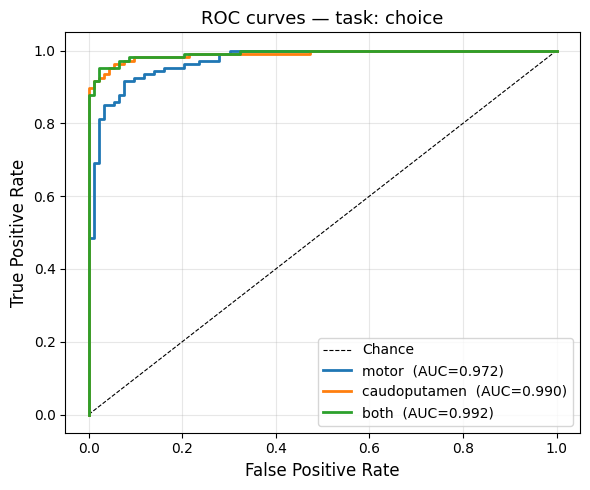

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance")

for label in cls_models:
    fpr, tpr, _ = roc_curve(cls_test_targets_arr[label], cls_test_probs[label])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f"{label}  (AUC={roc_auc:.3f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC curves — task: {TASK_CLS}", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
